Task 1 — Data Exploration with Pandas

In [8]:
data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as f:
    f.write(data)

In [44]:
df = pd.read_csv("students.csv")

1. First 5 rows

In [12]:
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


2. Shape + data types

In [13]:
df.shape
df.dtypes

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

3. Summary statistics

In [14]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


4. Pass vs Fail count

In [15]:
df['passed'].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

5. Average score per subject

In [16]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Pass:\n", pass_avg)
print("\nFail:\n", fail_avg)

Pass:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Fail:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


6. Student with highest average

In [17]:
df['avg_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]
top_student

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
avg_score               94.0
Name: 3, dtype: object

Task 2 — Data Visualization with Matplotlib

In [23]:
df['avg_score'] = df[subject_cols].mean(axis=1)

1. Bar Chart

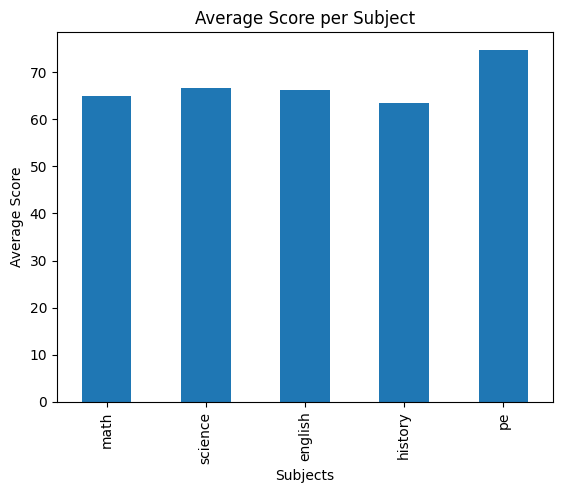

In [ ]:
df[subject_cols].mean().plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

2. Histogram

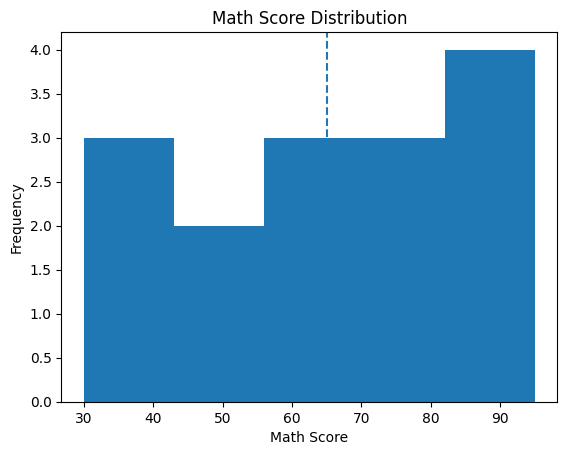

In [24]:
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.savefig("plot2_hist.png")
plt.show()

3. Scatter Plot

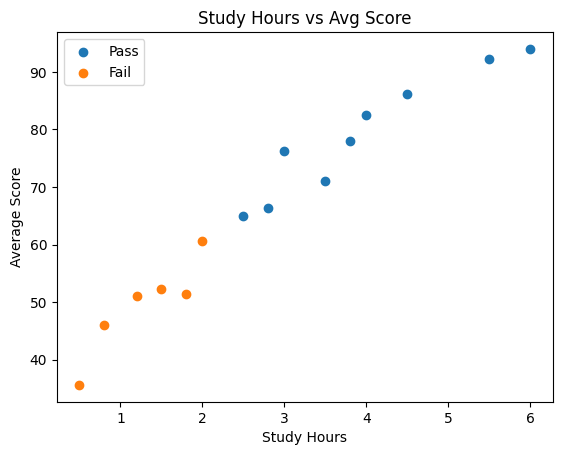

In [25]:
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study Hours vs Avg Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

4. Box Plot

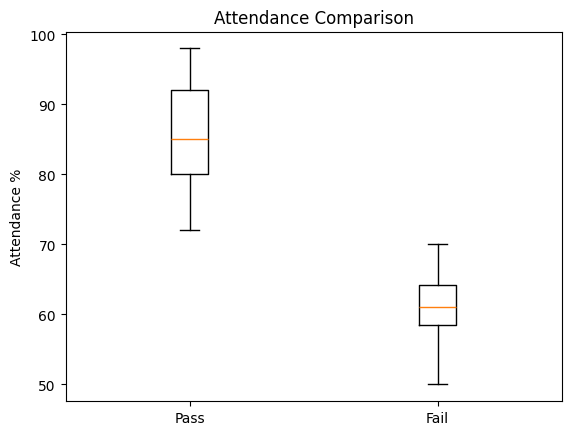

In [46]:
pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']

plt.boxplot([pass_att, fail_att], tick_labels=['Pass', 'Fail'])
plt.title("Attendance Comparison")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

5. Line Plot

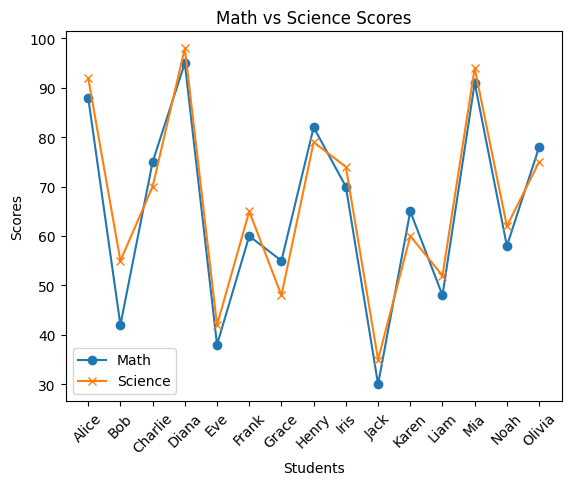

In [27]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.xlabel("Students")
plt.ylabel("Scores")
plt.title("Math vs Science Scores")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

Task 3 — Data Visualization with Seaborn

1. Seaborn Bar Plot

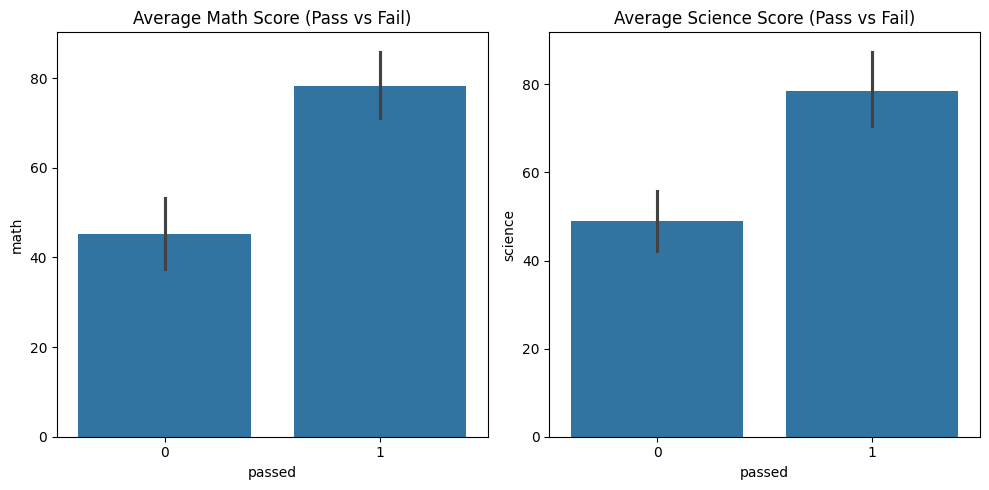

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# Math bar plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")

# Science bar plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")

plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()

2. Seaborn scatter plot

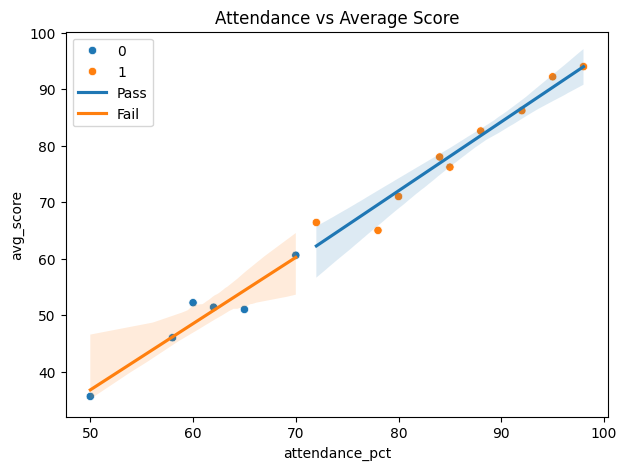

In [43]:
plt.figure(figsize=(7,5))

# Scatter plot
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.legend()
plt.savefig("seaborn_scatter.png")
plt.show()

In [ ]:
# Seaborn made it easier to create visually appealing and informative plots with less code compared to Matplotlib.
# Features like automatic grouping (hue) and built-in statistical plots (like regression lines) saved time.
# In contrast, Matplotlib required more manual customization for similar results.

Task 4 — Machine Learning with scikit-learn

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Step 1 — Prepare Data:

In [ ]:
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 2 — Train a Model:

In [32]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


Step 3 — Evaluate the Model:

In [33]:
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


In [34]:
test_indices = X_test.index

for i, idx in enumerate(test_indices):
    name = df.loc[idx, 'name']
    actual = y_test.iloc[i]
    pred = y_pred[i]
    print(name, "| Actual:", actual, "| Predicted:", pred)

Jack | Actual: 0 | Predicted: 0
Liam | Actual: 0 | Predicted: 0
Alice | Actual: 1 | Predicted: 1


Step 4 — Feature Importance:

In [35]:
coefficients = model.coef_[0]
features = X.columns

importance = pd.Series(coefficients, index=features).sort_values(key=abs, ascending=False)
print(importance)

english                0.812513
attendance_pct         0.521876
study_hours_per_day    0.484433
pe                     0.474974
math                   0.437944
science                0.323010
history                0.262929
dtype: float64


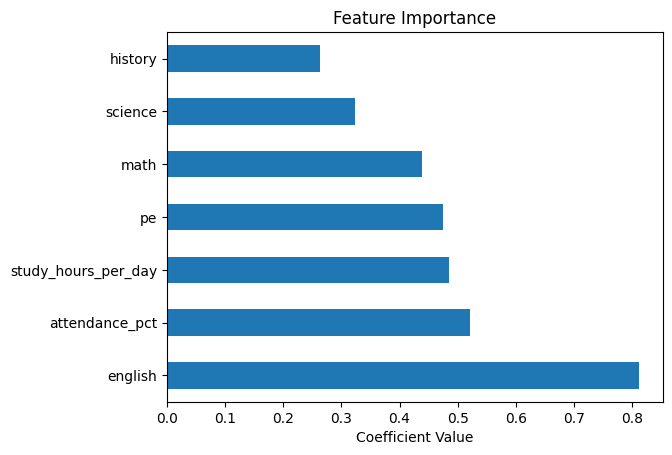

In [36]:
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.savefig("plot6_importance.png")
plt.show()

Step 5 — Predict for a New Student

In [45]:
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]],
    columns=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
)

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")
print("Probability:", probability)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]
